## Train Deep Learning Model

### step-1 load the preprocess data

In [2]:
import os
import numpy as np
import cv2
import gc

In [3]:
# load the preprocessed data
data = np.load('./data/data_preprocess.npz')

In [4]:
X = data['arr_0']
y = data['arr_1']

In [5]:
X.shape, y.shape

((9959, 100, 100, 3), (9959,))

### Preprocessing "y"

In [6]:
np.unique(y)

array(['Mask', 'Mask_Chin', 'Mask_Mouth_Chin', 'Mask_Nose_Mouth'],
      dtype='<U15')

In [7]:
from sklearn.preprocessing import OneHotEncoder

In [8]:
onehot = OneHotEncoder()
y_onehot = onehot.fit_transform(y.reshape(-1,1))

In [9]:
y_array = y_onehot.toarray()

### Split the Data into Train and Test sets

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y_array,test_size=0.2,random_state=42)

In [11]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((7967, 100, 100, 3), (1992, 100, 100, 3), (7967, 4), (1992, 4))

### Deep Learning Model

![cnn](cnn.png)

In [12]:
y_train

array([[0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       ...,
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.]], shape=(7967, 4))

In [13]:
cv2.imshow('a',x_train[-2])
cv2.waitKey()
cv2.destroyAllWindows()

In [14]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Sequential

In [15]:
# convolution neural network

model = Sequential([
    layers.Conv2D(16,3,padding='same',input_shape=(100,100,3),activation='relu'),
    layers.MaxPool2D(),
    layers.Conv2D(32,3,padding='same',activation='relu'),
    layers.MaxPool2D(),
    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.MaxPool2D(),
    layers.Flatten(),
    layers.Dense(192,activation='relu'),
    layers.Dense(28,activation='relu'),
    layers.Dense(4,activation='sigmoid')
])


# compiling CNN
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.categorical_crossentropy,metrics=['accuracy'])

d:\2_face_recognition_model\myvenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 192)            │     1,769,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 28)             │         5,404 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           116 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,798,768 (6.86 MB)

 Trainable params: 1,798,768 (6.86 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Training CNN
history = model.fit(x=x_train,y=y_train,validation_data=(x_test,y_test),batch_size=30,epochs=20)

Epoch 1/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.8998 - loss: 0.2687 - val_accuracy: 0.9684 - val_loss: 0.0918
Epoch 2/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9758 - loss: 0.0773 - val_accuracy: 0.9744 - val_loss: 0.0795
Epoch 3/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9836 - loss: 0.0511 - val_accuracy: 0.9809 - val_loss: 0.0501
Epoch 4/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9886 - loss: 0.0321 - val_accuracy: 0.9854 - val_loss: 0.0402
Epoch 5/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9878 - loss: 0.0259 - val_accuracy: 0.9799 - val_loss: 0.0668
Epoch 6/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9733 - loss: 0.0210 - val_accuracy: 0.9714 - val_loss: 0.0799
Epoch 7/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9941 - loss: 0.0129 - val_accuracy: 0.9839 - val_loss: 0.0397
Epoch 8/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9654 - loss: 0.0074 - val_accu

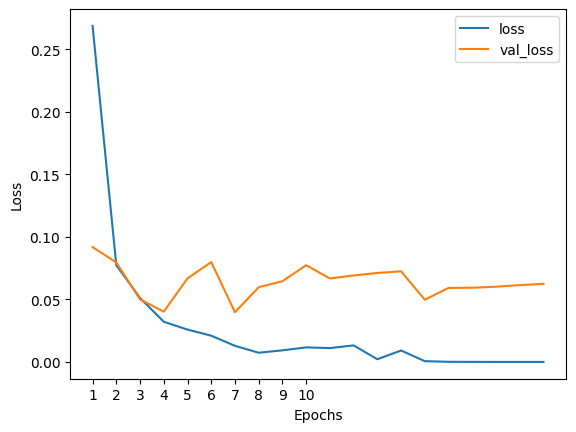

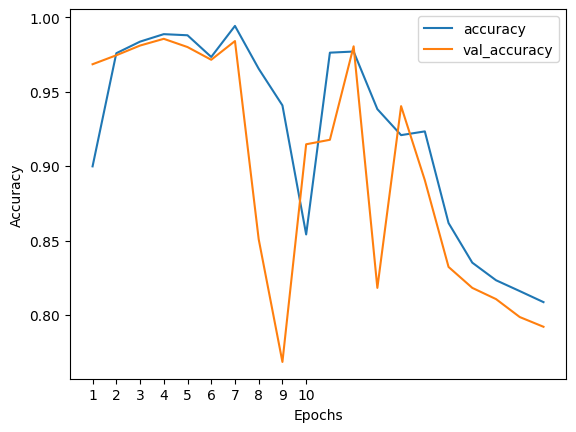

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history.history)

history_df

history_df[['loss','val_loss']].plot(kind='line')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(list(range(10)),list(range(1,11)))
plt.show()

history_df[['accuracy','val_accuracy']].plot(kind='line')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(list(range(10)),list(range(1,11)))
plt.show()



In [ ]:
# Save CNN Model
model.save('face_cnn_model.keras')

In [21]:
onehot.categories_

[array(['Mask', 'Mask_Chin', 'Mask_Mouth_Chin', 'Mask_Nose_Mouth'],
       dtype='<U15')]

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
history_df = pd.DataFrame(history.history)

In [24]:
history_df

,accuracy,loss,val_accuracy,val_loss
0,0.899837,0.268671,0.968373,0.091840
1,0.975775,0.077336,0.974398,0.079532
2,0.983557,0.051119,0.980924,0.050066
3,0.988578,0.032132,0.985442,0.040183
4,0.987825,0.025869,0.979920,0.066798
5,0.973265,0.020970,0.971386,0.079864
6,0.994101,0.012881,0.983936,0.039740
7,0.965357,0.007352,0.850904,0.059755
8,0.940756,0.009295,0.768574,0.064543
9,0.854148,0.011630,0.914659,0.077354
